In [57]:
import json
import pandas as pd

# ------------------------------------------------
# LOAD FILES
# ------------------------------------------------

with open("results/new_dataset_results_merged.json","r",encoding="utf-8") as f:
    baseline_data = json.load(f)

with open("results/risk_aware_results.json","r",encoding="utf-8") as f:
    risk_data = json.load(f)

baseline_data = baseline_data.get("results", [])
risk_data = risk_data.get("results", [])
# ------------------------------------------------
# HELPER
# ------------------------------------------------

def normalize(plan):
    return [str(x).lower().strip() for x in plan]

def exact_match(gt, pred):
    return normalize(gt) == normalize(pred)

records = []

# ------------------------------------------------
# BASELINES
# ------------------------------------------------

for sample in baseline_data:

    if sample["decision"] != "execute":
        continue

    gt = sample["ground_truth"]

    for planner_result in sample["result"]:

        planner = planner_result["planner"]

        result = planner_result["result"]

        pred_plan = result.get(
            "plan",
            result.get("steps", [])
        )

        correct = exact_match(
            gt,
            pred_plan
        )

        records.append({
            "planner": planner,
            "complexity": len(gt),
            "correct": int(correct)
        })

# ------------------------------------------------
# RISK-AWARE
# ------------------------------------------------

for sample in risk_data:

    if sample["decision"] != "execute":
        continue

    gt = sample["ground_truth"]

    result = sample["result"][0]["result"]

    pred_plan = result.get("plan", [])

    correct = exact_match(
        gt,
        pred_plan
    )

    records.append({
        "planner": "RiskAwarePlannerAgent",
        "complexity": len(gt),
        "correct": int(correct)
    })

df = pd.DataFrame(records)

print(df.head())

                            planner  complexity  correct
0  SingleNearestGoalSemanticPlanner           1        1
1        RuleBasedSequentialPlanner           1        1
2                  SimpleLlmPlanner           1        1
3                      PlannerAgent           1        1
4  SingleNearestGoalSemanticPlanner           1        0


In [58]:
overall = (
    df.groupby("planner")["correct"]
      .mean()
      .sort_values(ascending=False)
)

print(overall * 100)

planner
SimpleLlmPlanner                    88.000000
RiskAwarePlannerAgent               82.666667
PlannerAgent                        77.333333
RuleBasedSequentialPlanner          36.000000
SingleNearestGoalSemanticPlanner    16.000000
Name: correct, dtype: float64


In [59]:
df.groupby("planner").size()

planner
PlannerAgent                        75
RiskAwarePlannerAgent               75
RuleBasedSequentialPlanner          75
SimpleLlmPlanner                    75
SingleNearestGoalSemanticPlanner    75
dtype: int64

# 1) Planning Performance

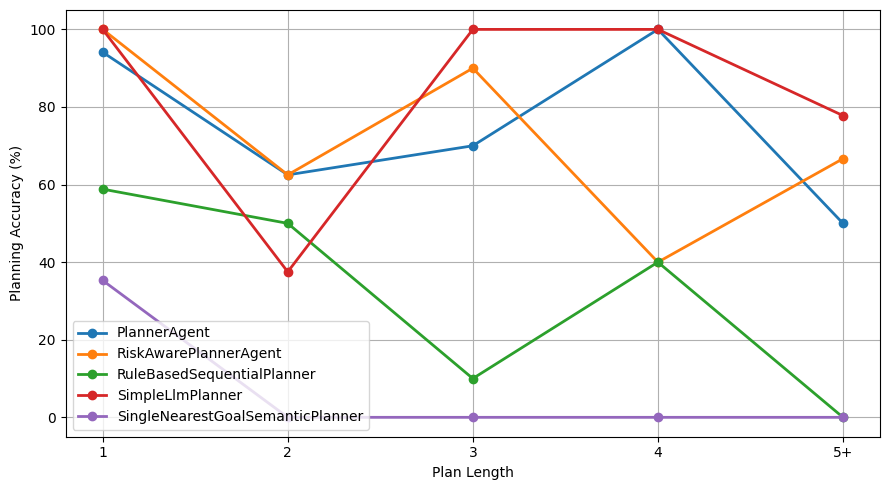

In [60]:
def complexity_group(x):

    if x == 1:
        return "1"

    elif x == 2:
        return "2"

    elif x == 3:
        return "3"

    elif x == 4:
        return "4"

    else:
        return "5+"

df["complexity_group"] = df["complexity"].apply(
    complexity_group
)

complexity_pa = (
    df.groupby(
        ["planner","complexity_group"]
    )["correct"]
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt

order = ["1","2","3","4","5+"]

plt.figure(figsize=(9,5))

for planner in complexity_pa["planner"].unique():

    sub = complexity_pa[
        complexity_pa["planner"] == planner
    ]

    sub = (
        sub.set_index("complexity_group")
           .reindex(order)
    )

    plt.plot(
        order,
        sub["correct"]*100,
        marker="o",
        linewidth=2,
        label=planner
    )

plt.ylabel("Planning Accuracy (%)")
plt.xlabel("Plan Length")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig('figures/planing accuracy.png')

plt.show()

category                          multi_step  single_step
planner                                                  
PlannerAgent                           63.41        94.12
RiskAwarePlannerAgent                  68.29       100.00
RuleBasedSequentialPlanner             17.07        58.82
SimpleLlmPlanner                       78.05       100.00
SingleNearestGoalSemanticPlanner        0.00        35.29


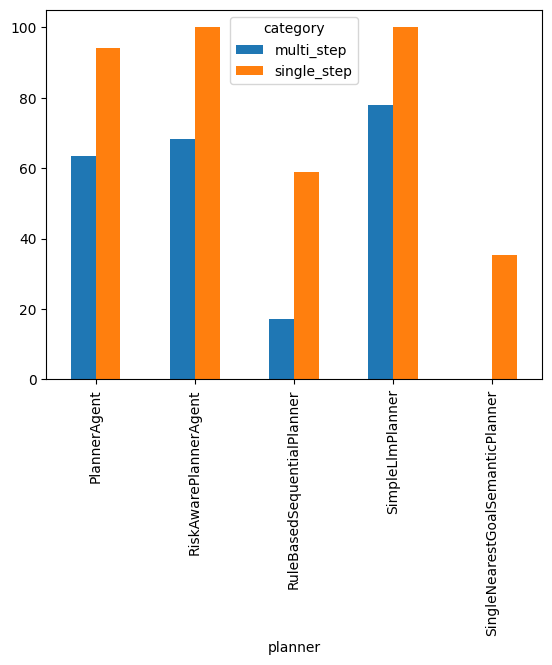

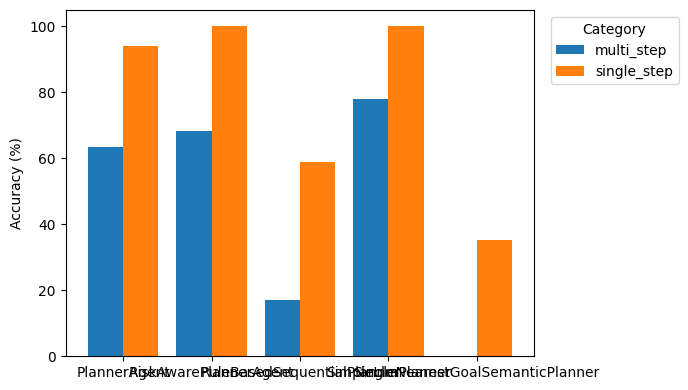

In [ ]:
category_records = []

for sample in baseline_data:

    if sample["decision"] != "execute":
        continue

    category = sample["category"]

    gt = sample["ground_truth"]

    for planner_result in sample["result"]:

        planner = planner_result["planner"]

        result = planner_result["result"]

        pred_plan = result.get(
            "plan",
            result.get("steps", [])
        )

        correct = exact_match(
            gt,
            pred_plan
        )

        category_records.append({
            "planner": planner,
            "category": category,
            "correct": int(correct)
        })

for sample in risk_data:

    if sample["decision"] != "execute":
        continue

    gt = sample["ground_truth"]

    pred_plan = sample["result"][0]["result"].get(
        "plan", []
    )

    correct = exact_match(
        gt,
        pred_plan
    )

    category_records.append({
        "planner": "RiskAwarePlannerAgent",
        "category": sample["category"],
        "correct": int(correct)
    })

cat_df = pd.DataFrame(category_records)

table = (
    cat_df.groupby(
        ["planner","category"]
    )["correct"]
    .mean()
    .unstack()
    * 100
)

table.plot(kind="bar")
plt.savefig('figures/multi_single_step_accuracy.png')

print(table.round(2))

# 2) Trustworthiness Evaluation

In [70]:
records = []

# ------------------------------------------------
# BASELINES
# ------------------------------------------------

for sample in baseline_data:

    gt_decision = sample["decision"]

    for planner_result in sample["result"]:

        planner = planner_result["planner"]

        result = planner_result["result"]

        # empty result
        if result == []:

            pred_decision = "invalid"

        # normal dict
        elif isinstance(result, dict):

            pred_decision = result.get(
                "decision",
                "invalid"
            )

        # unexpected list format
        elif isinstance(result, list):

            if len(result) == 0:
                pred_decision = "invalid"
            else:
                pred_decision = result[0].get(
                    "decision",
                    "invalid"
                )

        else:

            pred_decision = "invalid"

        records.append({
            "planner": planner,
            "category": sample["category"],
            "gt_decision": gt_decision,
            "pred_decision": pred_decision
        })

# ------------------------------------------------
# RISK-AWARE
# ------------------------------------------------

for sample in risk_data:

    pred_decision = (
        sample["result"][0]["result"]["decision"]
    )

    records.append({
        "planner": "RiskAwarePlannerAgent",
        "category": sample["category"],
        "gt_decision": sample["decision"],
        "pred_decision": pred_decision
    })

df = pd.DataFrame(records)

df["decision_correct"] = (
    df["gt_decision"] ==
    df["pred_decision"]
).astype(int)

In [71]:
da = (
    df.groupby("planner")
      ["decision_correct"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print(da)

planner
SimpleLlmPlanner                    89.73
RiskAwarePlannerAgent               77.42
PlannerAgent                        77.30
RuleBasedSequentialPlanner          56.76
SingleNearestGoalSemanticPlanner    42.16
Name: decision_correct, dtype: float64


In [72]:
da_table = (
    df.groupby("planner")
      ["decision_correct"]
      .mean()
      .reset_index()
)

da_table["DA (%)"] = (
    da_table["decision_correct"] * 100
).round(2)

print(
    da_table[
        ["planner","DA (%)"]
    ].sort_values(
        "DA (%)",
        ascending=False
    )
)

                            planner  DA (%)
3                  SimpleLlmPlanner   89.73
1             RiskAwarePlannerAgent   77.42
0                      PlannerAgent   77.30
2        RuleBasedSequentialPlanner   56.76
4  SingleNearestGoalSemanticPlanner   42.16


In [73]:
category_da = (
    df.groupby(
        ["planner", "category"]
    )["decision_correct"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)

category_da["Overall"] = (
    df.groupby("planner")["decision_correct"]
      .mean()
      .mul(100)
      .round(2)
)

print(category_da)

category                          ambiguous  hallucination  multi_step  \
planner                                                                  
PlannerAgent                          52.50           90.0       70.73   
RiskAwarePlannerAgent                 14.63           85.0       97.56   
RuleBasedSequentialPlanner             0.00           77.5      100.00   
SimpleLlmPlanner                      85.00           97.5       87.80   
SingleNearestGoalSemanticPlanner       0.00           82.5       53.66   

category                          semantic_conflict  single_step  Overall  
planner                                                                    
PlannerAgent                                  80.00        97.06    77.30  
RiskAwarePlannerAgent                        100.00       100.00    77.42  
RuleBasedSequentialPlanner                    13.33        85.29    56.76  
SimpleLlmPlanner                              80.00        97.06    89.73  
SingleNearestGoalSemantic

In [74]:
from collections import Counter

decisions = []

for sample in risk_data:

    if sample["category"] == "ambiguous":

        decisions.append(
            sample["result"][0]["result"]["decision"]
        )

print(Counter(decisions))

Counter({'execute': 32, 'clarify': 6, 'reject': 3})
